<a href="https://colab.research.google.com/github/Hibah-Raza/Hibah-Raza/blob/main/FacialExpressionIdentification_CP468_Group_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Introduction**

Our facial expression indentification using pre-trained models is a deep-learning application in artificial inteligence. This project proposes to use pre-trained convolutional neural network models to recognize and categorize facial expressions such as angry, disgust, fear, happy, neutral, sad, and surpise. The initiative, which builds on prior research and improvements in transfer learning, seeks to enhance emotion indentification skills in real-world settings ranging from mental health to human-computer systems.

####**Our Two Key Phases:**

**Phase 1:** Designing and implementing a customized CNN model for facial expression indentification using TensorFlow and Keras.

**Phase 2:** Experimenting with pre-trained models and esemble learning
the Google TensorFlow API and Gradio.

####**Our Plan:**

To compare the preformance of our custom-built model to pre-trained models and access their ability to indentify facial expressions.

####**Project Team:**
Hibah Hibah: 169033490

Iman Chaudhry: 210650820

Arrangan Kathir: 169042354

Brandon Dang: 169026034

Tyler Rizzi: 169022274

In [40]:
# Installation
# !pip install tensorflow gradio # installs tensorflow and gradio (only when needed for installation)
# Imports
import tensorflow as tf # imports tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator # imports imagedatagenerator from keras
from tensorflow.keras import layers, models # imports layers and models module from tensorflow.keras
import numpy as np # imports numpy
from PIL import Image # imports image from python imaging library
import gradio as gr # imports gradio
import matplotlib.pyplot as plt # imports matplotlib for plotting
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3 # imports 3 pre-trained models
from tensorflow.keras.models import Model # imports models

##**Data Preperation**
For this project, we use the FER-2013 dataset, which is availabe on Kaggle. This dataset contains 35,887 grayscale images of faces, labeled with one of the seven expressions: happy, sad, angry, surprised, fear, disgust, or neutral. Each picture is a 48x48 pixels in size.

####**Our Steps for Preperation**
**Step 1:** Dataset Loading: Loading FER-2013 dataset from Kaggle and uploading it to our Google Collab enivornment.

**Step 2:** Dataset Preprocessing: Preprocessing the images by adjusting their pixel values and resizing them to our models required input size.

**Step 3:** Data Augumentation: Using data augumentation such as horizonal flipping, zooming, and rotation to boost the variety of our training data which will prevent any overfitting.

**Step 4:** Data Splitting: To analyze our models preformance, the dataset is divided in three sets these will be training, validation, and testing.

In [ ]:
# Uploading file to google collab
from google.colab import files
uploaded = files.upload()

import zipfile
import os

for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall('/content/CP468/dataset')


In [31]:
# Imports
import tensorflow as tf # imports tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator # imports imagedatagenerator from keras

# Data Stored
##dataset_dir = '/content/CP468/dataset'

train_dir = '/content/CP468/dataset/train'
test_dir = '/content/CP468/dataset/test'

# For Rescaling and Data Augumentation Creating a ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255, # will rescale pixels to be between 0 and 1 and not 0 and 255
                             validation_split=0.2, # 20% of the data is reserved for validation
                             rotation_range=20, # rotates images randomly within range of 20 degrees
                             width_shift_range=0.2, # shifts images randomly horizontally by 20% width
                             height_shift_range=0.2, # shifts images randomly vertically by 20% height
                             shear_range=0.2, # handles random shear transformations
                             zoom_range=0.2, # will randomly zoom inside images
                             horizontal_flip=True, # will randomly flip images horizontally
                             fill_mode='nearest' # will specificy how to fill in images that could appear after any rotation/width/height shift
                            )

# Generators Created for Validation and Training

#Creates a Generator for Validation Data
validation_generator = datagen.flow_from_directory(test_dir, # contains the validation data
                                                   target_size=(48, 48), # resizes images to 48x48 pixels
                                                   color_mode='grayscale', # images are converted to grayscale
                                                   batch_size=32, # specifies size of the batches of data which will be 32 images per batch
                                                   class_mode='categorical', # will indicate the labels to be categorical which are one-hot encode labels
                                                   )

#Creates a Generator for Training Data
train_generator = datagen.flow_from_directory(train_dir, # contains the training data
                                              target_size=(48, 48), # resizes images to 48x48 pixels
                                              color_mode='grayscale', # images are converted to grayscale
                                              batch_size=32, # specifies size of the batches of data which will be 32 images per batch
                                              class_mode='categorical', # will indicate the labels to be categorical which are one-hot encode labels
                                              )

# Class Indicies
print(train_generator.class_indices) # displays the output of mapping of class names to integer labels

Found 7178 images belonging to 7 classes.
Found 28709 images belonging to 7 classes.
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


#**CNN MODEL**

###***Phase 1: Our Custom CNN Model Design and Implementation***

To classify facial expressions, we built a simple CNN model with TensorFlow and Keras API. The model design starts with multiple convolutional layers, then max-pooling layers, next a flattening layer, and lastly dense layers. Our implementation attempts to provide simple knowldge of CNN and its application in image classification problems, specifically for facial expression indentification.

#**Model Architecture**

####**What Our Architecture Includes**

**Conv2D Layers:** A convolutional process extracts features from an input picture.

**MaxPooling2D Layers:** Reduces spatial dimentions of feature maps, lowering computational load and reuducing overfitting.

**Flatten Layer:** Converts the 2D feature maps to 1D feature vectors in preperation for fully connecting layers.

**Dense Layers:** Fully connected layers that conduct categorization using the extracted features.


In [ ]:
# Imports
from tensorflow.keras import layers, models # imports layers and models module from tensorflow.keras

# Custom CNN Model
model = models.Sequential() # initializes a sequential model, to add layers to our model sequentially

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1))) # adding 2D convolutional layer, 32 number of filters, height and width 3,3
model.add(layers.MaxPooling2D((2, 2))) # adds a max pooling layer, size of pooling window is 2,2 height and width

model.add(layers.Conv2D(64, (3, 3), activation='relu')) # adding 2D convolutional layer, 64 number of filters, height and width 3,3
model.add(layers.MaxPooling2D((2, 2))) # adds a max pooling layer, size of pooling window is 2,2 height and width

model.add(layers.Conv2D(64, (3, 3), activation='relu')) # adding 2D convolutional layer, 64 number of filters, height and width 3,3

model.add(layers.Flatten()) # flattens the layer to turn into 1D array

model.add(layers.Dense(64, activation='relu')) # adds dense layer with 64 units
model.add(layers.Dense(7, activation='softmax')) # adds dense outpput later with 7 units and corresponds to the number of classses in our task

model.compile(optimizer='adam', # adam optimizer used with is a adaptive learning rate algorithm
              loss='categorical_crossentropy', #specifies the loss part of the function
              metrics=['accuracy']) # specifcies the metric which will be evaluated during both the training and testing

model.summary() # will print summary of the model architecture, number of layers, output shaps and number of parameters within each layers

Epoch 1/10
898/898 [==============================] - 122s 136ms/step - loss: 1.3880 - accuracy: 0.4642 - val_loss: 1.3745 - val_accuracy: 0.4684
Epoch 2/10
898/898 [==============================] - 125s 139ms/step - loss: 1.3711 - accuracy: 0.4714 - val_loss: 1.3564 - val_accuracy: 0.4790
Epoch 3/10
898/898 [==============================] - 117s 130ms/step - loss: 1.3614 - accuracy: 0.4778 - val_loss: 1.3449 - val_accuracy: 0.4792
Epoch 4/10
898/898 [==============================] - 125s 139ms/step - loss: 1.3495 - accuracy: 0.4812 - val_loss: 1.3486 - val_accuracy: 0.4801
Epoch 5/10
898/898 [==============================] - 115s 128ms/step - loss: 1.3374 - accuracy: 0.4885 - val_loss: 1.3354 - val_accuracy: 0.4923
Epoch 6/10
898/898 [==============================] - 117s 130ms/step - loss: 1.3281 - accuracy: 0.4888 - val_loss: 1.3184 - val_accuracy: 0.4897
Epoch 7/10
898/898 [==============================] - 116s 129ms/step - loss: 1.3148 - accuracy: 0.4953 - val_loss: 1.3122 -

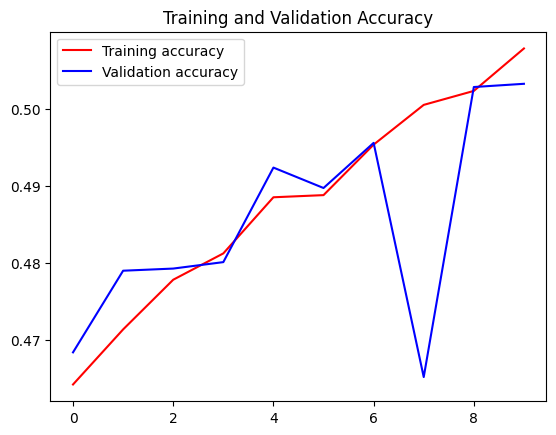

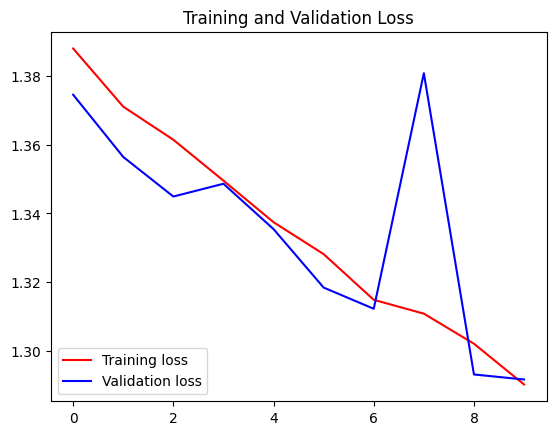

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Imports
import matplotlib.pyplot as plt # imports matplotlib for plotting

# Training Our Custom CNN Model
history = model.fit(train_generator, epochs=10, validation_data=validation_generator) # 10 epochs used for training which is the number of times training dataset is passed through

# Our CNN Model Validation Accuracy + Loss

# Accuracy
acc = history.history['accuracy'] # metrics for each epoch
val_acc = history.history['val_accuracy'] # extracts training accuracy
loss = history.history['loss'] # extracts training loss
val_loss = history.history['val_loss'] # extracts validation loss

epochs = range(len(acc)) # creates range representing the 10 numbers of epochs used for the x-axis of the graph

plt.figure() # creates a new figure for the plot
plt.plot(epochs, acc, 'r', label='Training accuracy') # plots training accuracy with red line
plt.plot(epochs, val_acc, 'b', label='Validation accuracy') # plots validation accuracy with blue line
plt.title('Training and Validation Accuracy') # sets title
plt.legend() # displays legend
plt.show() # displays plot

# Loss
plt.figure() # creates a new figure for the plot
plt.plot(epochs, loss, 'r', label='Training loss') # plots the training loss with red line
plt.plot(epochs, val_loss, 'b', label='Validation loss') # plots the validation loss with blue line
plt.title('Training and Validation Loss') # sets title
plt.legend() # displays legend
plt.show() # displays plot

# Saved Model
model.save('facial_expression_indentification_cnn_model.h5') # saving the model to a file and file is saved as an extension of HDF5 format

##**3 Pre-Trained Models and Interface**

###***Phase 2: Experimenting with Pre-Trained Models***

####We use pre-trained models to recognize facial expressions using transfer learning. For this project, we used fine-tuned models like VGG16, ResNet50, InceptionV3.

###**The 3 Pre-Trained Models Used**

**VGG16** - https://keras.io/api/applications/vgg/#vgg16-function

**ResNet50** - https://keras.io/api/applications/resnet/#resnet50-function

**InceptionV3** - https://keras.io/api/applications/inceptionv3/

In [39]:
# Imports
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3 # this imports the pre-trained models
import gradio as gr # imports gradio

# Pre-Trained Model VGG16
def create_vgg16_model(num_classes):
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3))
  x = base_model.output
  x = Flatten()(x)
  x = Dense(1024, activation='relu')(x)
  predictions = Dense(num_classes, activation='softmax')(x)
  model = Model(inputs=base_model.input, outputs=predicitions)

  for layer in base_model.layers:
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

num_classes = train_generator.num_classes
vgg16_model = create_vgg16_model(num_classes)

vgg16_model.fit(train_generator, epochs=10, validation_data=val_generator)

# Pre-Trained Model ResNet50
def create_resnet50_model(num_classes):
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3))
  x = base_model.output
  x = Flatten()(x)
  x = Dense(1024, activation='relu')(x)
  predictions = Dense(num_classes, activation='softmax')(x)
  model = Model(inputs=base_model.input, outputs=predicitions)


  for layer in base_model.layers:
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

resnet50_model = create_resnet50_model(num_classes)
resnet50_model.fit(train_generator, epochs=10, validation_data=val_generator)

# Pre-Trained Model InceptionV3
def create_inceptionv3_model(num_classes):
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3))
  x = base_model.output
  x = Flatten()(x)
  x = Dense(1024, activation='relu')(x)
  predictions = Dense(num_classes, activation='softmax')(x)
  model = Model(inputs=base_model.input, outputs=predicitions)

  for layer in base_model.layers:
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

inceptionv3_model = create_inceptionv3_model(num_classes)
inceptionv3_model.fit(train_generator, epochs=10, validation_data=val_generator)

# Pre-Trained Model Interfaces Using Gradio
def predict_image(model, img):
  img = img.resize((244, 244))
  img = np.array(img) / 255.0
  img = np.expand_dims(img, axis=0)
  prediction = model.predict(img)
  print(prediction)
  return prediction
  #return train_generator.class_indices.keys[np.argmax(prediction)]

vgg16_interface = gr.Interface(fn=lambda img: predict_image(vgg16_model, img), inputs="image", outputs="text")
# Model 1 Interface
#vgg16_interface = gr.Interface(fn=lambda img: predict_image(vgg16_model, img), inputs="image", outputs="text")

# Model 2 Interface
# resnet50_interface = gr.Interface(fn=lambda img: predict_image(resnet50_model, img), inputs="image", outputs="text")

# Model 3 Interface
# inceptionv3_interface = gr.Interface(fn=lambda img: predict_image(inceptionv3_model, img), inputs="image", outputs="text")

# Launching the Gradio Interface
vgg16_interface.launch()
#resnet50_interface.launch()
#inceptionv3_interface.launch()

58889256/58889256 [==============================] - 1s 0us/step


NameError: name 'Flatten' is not defined

In [ ]:
# prompt:

!pip install --upgrade tensorflow


##**Gradio Interface for Our Model**

We developed a Gradio interface to test our model on imagery and monitor their predicitions.

In [19]:
# Imports
import gradio as gr

# num_classes = train_generator.num_classes

# the lass names
class_names =["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# model = create_custom_cnn_model(num_classes)
# model.fit(train_generator, epochs=10, validation_data=val_generator)

#
def classify_image(img):
  img = img.convert('L')
  img = img.resize((48, 48))
  img = np.array(img) / 225.0
  img = np.expand_dims(img, axis=-1)
  img = np.expand_dims(img, axis=0)
  prediction = model.predict(img)

  #
  return {class_names[i]: float(prediction[0][i]) for i in range(7)}

  #
  iface = gr.Interface(fn=classify_image, inputs="image", outputs="label")

  # launch the gradio interface
  iface.launch()

#**Facial Expression Identification AI Model - CP468 Group 6**

Found 7178 images belonging to 7 classes.
Found 28709 images belonging to 7 classes.
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Con

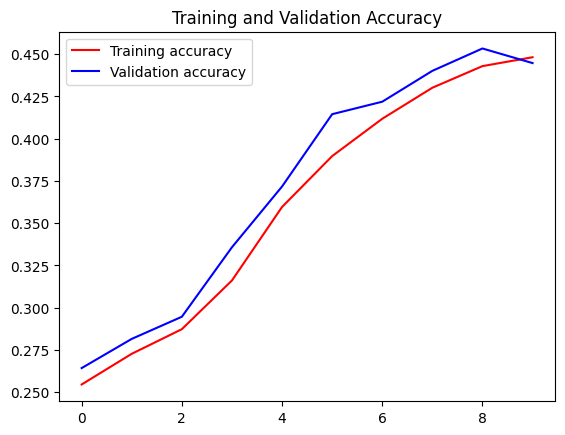

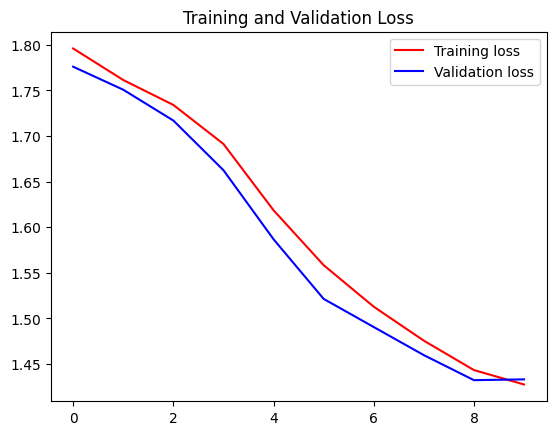

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://df902a78de0eadacf0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://722bd4dafc88452910.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://c9c425985c73b164ef.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://65077fdb2d9971f6a0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [32]:
# Imports
import tensorflow as tf # imports tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator # imports imagedatagenerator from keras
from tensorflow.keras import layers, models # imports layers and models module from tensorflow.keras
import numpy as np # imports numpy
from PIL import Image # imports image from python imaging library
import gradio as gr # imports gradio
import matplotlib.pyplot as plt # imports matplotlib for plotting
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3 # imports 3 pre-trained models
from tensorflow.keras.models import Model # imports models

# Dataset Directorys
train_dir = '/content/CP468/dataset/train'
test_dir = '/content/CP468/dataset/test'

# Augumentation and Rescaling
datagen = ImageDataGenerator(rescale=1./255, # will rescale pixels to be between 0 and 1 and not 0 and 255
                             validation_split=0.2, # 20% of the data is reserved for validation
                             rotation_range=20, # rotates images randomly within range of 20 degrees
                             width_shift_range=0.2, # shifts images randomly horizontally by 20% width
                             height_shift_range=0.2, # shifts images randomly vertically by 20% height
                             shear_range=0.2, # handles random shear transformations
                             zoom_range=0.2, # will randomly zoom inside images
                             horizontal_flip=True, # will randomly flip images horizontally
                             fill_mode='nearest' # will specificy how to fill in images that could appear after any rotation/width/height shift
                            )

# Data Generators for Validation and Training
validation_generator = datagen.flow_from_directory(test_dir, # contains the validation data
                                                   target_size=(48, 48), # resizes images to 48x48 pixels
                                                   color_mode='grayscale', # images are converted to grayscale
                                                   batch_size=32, # specifies size of the batches of data which will be 32 images per batch
                                                   class_mode='categorical', # will indicate the labels to be categorical which are one-hot encode labels
                                                   )

train_generator = datagen.flow_from_directory(train_dir, # contains the training data
                                              target_size=(48, 48), # resizes images to 48x48 pixels
                                              color_mode='grayscale', # images are converted to grayscale
                                              batch_size=32, # specifies size of the batches of data which will be 32 images per batch
                                              class_mode='categorical', # will indicate the labels to be categorical which are one-hot encode labels
                                              )

# Class Indicies
print(train_generator.class_indices) # displays the output of mapping of class names to integer labels

# Our Custom CNN Model
model = models.Sequential() # initializes a sequential model, to add layers to our model sequentially

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1))) # adding 2D convolutional layer, 32 number of filters, height and width 3,3
model.add(layers.MaxPooling2D((2, 2))) # adds a max pooling layer, size of pooling window is 2,2 height and width

model.add(layers.Conv2D(64, (3, 3), activation='relu')) # adding 2D convolutional layer, 64 number of filters, height and width 3,3
model.add(layers.MaxPooling2D((2, 2))) # adds a max pooling layer, size of pooling window is 2,2 height and width

model.add(layers.Conv2D(64, (3, 3), activation='relu')) # adding 2D convolutional layer, 64 number of filters, height and width 3,3

model.add(layers.Flatten()) # flattens the layer to turn into 1D array

model.add(layers.Dense(64, activation='relu')) # adds dense layer with 64 units
model.add(layers.Dense(7, activation='softmax')) # adds dense outpput later with 7 units and corresponds to the number of classses in our task

model.compile(optimizer='adam', # adam optimizer used with is a adaptive learning rate algorithm
              loss='categorical_crossentropy', #specifies the loss part of the function
              metrics=['accuracy']) # specifcies the metric which will be evaluated during both the training and testing

model.summary() # will print summary of the model architecture, number of layers, output shaps and number of parameters within each layers

# Training our Custom CNN Model
history = model.fit(train_generator, epochs=10, validation_data=validation_generator) # 10 epochs used for training which is the number of times training dataset is passed through

# Plotting the Validation and Training Accuracy

# Accuracy
acc = history.history['accuracy'] # metrics for each epoch
val_acc = history.history['val_accuracy'] # extracts training accuracy
loss = history.history['loss'] # extracts training loss
val_loss = history.history['val_loss'] # extracts validation loss

epochs = range(len(acc)) # creates range representing the 10 numbers of epochs used for the x-axis of the graph

plt.figure() # creates a new figure for the plot
plt.plot(epochs, acc, 'r', label='Training accuracy') # plots training accuracy with red line
plt.plot(epochs, val_acc, 'b', label='Validation accuracy') # plots validation accuracy with blue line
plt.title('Training and Validation Accuracy') # sets title
plt.legend() # displays legend
plt.show() # displays plot

# Loss
plt.figure() # creates a new figure for the plot
plt.plot(epochs, loss, 'r', label='Training loss') # plots the training loss with red line
plt.plot(epochs, val_loss, 'b', label='Validation loss') # plots the validation loss with blue line
plt.title('Training and Validation Loss') # sets title
plt.legend() # displays legend
plt.show() # displays plot

# Saved Model
model.save('facial_expression_indentification_cnn_model.h5') # saving the model to a file and file is saved as an extension of HDF5 format

# Class Names
class_names =["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Pre-Trained Models

# Pre-Trained Model VGG16
def create_vgg16_model(num_classes): # class made for the model
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3)) # loading the model
  x = base_model.output # get output for base model
  x = Flatten()(x) # flatten output into fully connected layers
  x = Dense(1024, activation='relu')(x) # add connected layer fully with 1024 units
  predictions = Dense(num_classes, activation='softmax')(x) # add output layer with num_classes units
  model = Model(inputs=base_model.input, outputs=predicitions) # create new model by specifying input and output

  for layer in base_model.layers: # these two lines of code freeze the layers to prevent them from being trained of any sort
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # compiling with adam optimizer and etc
  return model

  num_classes = train_generator.num_classes # getting number of classes from the training generator
  vgg16_model = create_vgg16_model(num_classes) # create vgg16 model with a specificed number of classes

  vgg16_model.fit(train_generator, epochs=10, validation_data=val_generator) # train the vgg16 model using the training data, for 10 epochs with the validation data

# Pre-Trained Model ResNet50
def create_resnet50_model(num_classes): # class made for the model
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3))  # loading the model
  x = base_model.output # get output for base model
  x = Flatten()(x)  # flatten output into fully connected layers
  x = Dense(1024, activation='relu')(x) # add connected layer fully with 1024 units
  predictions = Dense(num_classes, activation='softmax')(x) # add output layer with num_classes units
  model = Model(inputs=base_model.input, outputs=predicitions) # create new model by specifying input and output

  for layer in base_model.layers: # these two lines of code freeze the layers to prevent them from being trained of any sort
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # compiling with adam optimizer and etc
  return model

  resnet50_model = create_resnet50_model(num_classes) # getting number of classes from the training generator
  resnet50_model.fit(train_generator, epochs=10, validation_data=val_generator) # create resnet50 model with a specificed number of classes

# Pre-Trained Model InceptionV3
def create_inceptionv3_model(num_classes): # class made for the model
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(244, 244, 3))  # loading the model
  x = base_model.output # get output for base model
  x = Flatten()(x)  # flatten output into fully connected layers
  x = Dense(1024, activation='relu')(x) # add connected layer fully with 1024 units
  predictions = Dense(num_classes, activation='softmax')(x) # add output layer with num_classes units
  model = Model(inputs=base_model.input, outputs=predicitions) # create new model by specifying input and output

  for layer in base_model.layers: # these two lines of code freeze the layers to prevent them from being trained of any sort
    layer.trainable = False

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # compiling with adam optimizer and etc
  return model

  inceptionv3_model = create_inceptionv3_model(num_classes) # getting number of classes from the training generator
  inceptionv3_model.fit(train_generator, epochs=10, validation_data=val_generator) # create inceptionv3 model with a specificed number of classes

# Gradio Interface
def predict_image(model, img): # class made for interface
  img = img.resize((244, 244)) # resize the input images to a 244x244
  img = np.array(img) / 255.0 # converting the image to a numpy
  img = np.expand_dims(img, axis=0) # expanding the dimensions of the image array
  prediction = model.predict(img) # making a prediction using the model
  return train_generator.class_indices.keys[np.argmax(prediction)] # returning the class label with the highest predicition probability

# Gradio Pre-Trained Models Interface
vgg16_interface = gr.Interface(fn=lambda img: predict_image(vgg16_model, img), inputs="image", outputs="text") # these two lines create and launch the gradio interface for the first model
vgg16_interface.launch()

resnet50_interface = gr.Interface(fn=lambda img: predict_image(resnet50_model, img), inputs="image", outputs="text")  # these two lines create and launch the gradio interface for the second model
resnet50_interface.launch()

inceptionv3_interface = gr.Interface(fn=lambda img: predict_image(inceptionv3_model, img), inputs="image", outputs="text")  # these two lines create and launch the gradio interface for the third model
inceptionv3_interface.launch()

# Custom CNN Model Gradio Interface
def classify_image(img): # creates a class for our custom cnn model interface
  img = img.convert('L') # converting the image to grayscale
  img = img.resize((48, 48)) # resizing image to 48x48 pixels
  img = np.array(img) / 225.0 # converting the image to numpy array
  img = np.expand_dims(img, axis=-1) # these two lines expands the dimensions of the image array so it can match the model input
  img = np.expand_dims(img, axis=0)  # these two lines expands the dimensions of the image array so it can match the model input
  prediction = model.predict(img) # making a prediction using our custom model
  return {class_names[i]: float(prediction[0][i]) for i in range(7)} # return a dictionary with class names and the corresponding predicted probabilities

# Launch the gradio interface
iface = gr.Interface(fn=classify_image, inputs="image", outputs="label") # these two lines launch our custom cnn model gradio interface
iface.launch() # these two lines launch our custom cnn model gradio interface


